# Week 6 – Filter Spasial (PCVK)
**Modul 6: Low Pass Filter, High Pass Filter, Point Detection, Line Detection, Edge Detection**

In [1]:
# ===== Cell Identitas =====
NAMA = 'Nabhan Rizqi Julian Saputro'
NIM  = '2341720255'          
print(NAMA, NIM)

Nabhan Rizqi Julian Saputro 2341720255


In [2]:
# Mount Google Drive (hanya jalan di Colab; di komputer lokal dilewati)
from sqlalchemy import false , true
drive = false

try:
    from google.colab import drive
    drive.mount('/content/drive')
    drive = true
except ImportError:
    print('Bukan Google Colab -> Jalan Di local')

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math

# from google.colab.patches import cv2_imshow
from PIL import Image as im

# Folder tempat gambar disimpan (SESUAIKAN)
if drive == true :
    PATH = '/content/drive/MyDrive/Kuliah/Semester5/PCVK/Img'
else :
    PATH = 'IMG'


Bukan Google Colab -> Jalan Di local


### Fungsi bantu

1. `baca(nama)` – membaca gambar **dan langsung memeriksa** hasilnya. `cv.imread` tidak error bila path salah, ia hanya mengembalikan `None`, sehingga error baru muncul jauh di bawah dan membingungkan. Lebih baik gagal cepat dengan pesan jelas.
2. `show_side_by_side` – fungsi dari modul: citra 2D ditampilkan sebagai grayscale, citra 3D (BGR) dikonversi ke RGB dulu karena `matplotlib` mengharapkan RGB sedangkan OpenCV memakai BGR.
3. `ke_uint8(x, mode)` – hasil konvolusi adalah **float** dan bisa negatif/lebih dari 255. Sebelum ditampilkan harus dipetakan ke 0–255. Cara pemetaan **bergantung jenis filter**:

| mode | rumus | cocok untuk | alasan |
|---|---|---|---|
| `clip` | potong ke 0–255 | Sharpen, Blur, Average, Low Pass | jumlah kernel = 1, hasil masih sebaran terang yang wajar |
| `abs` | \|x\| lalu potong | Sobel, Prewitt, Laplacian, Point/Line detection | yang penting **kekuatan** respons, arah (tanda +/−) tidak dipentingkan |
| `offset` | x + 128 lalu potong | Emboss | tanda +/− = naik/turun terang; digeser ke abu-abu tengah supaya kesan relief terlihat |
| `minmax` | skala min→0, max→255 | High Pass / hasil yang rentangnya tak diketahui | memakai seluruh rentang kontras agar tidak "hitam semua" |

In [3]:
def baca(nama, mode=cv.IMREAD_COLOR):
    # Baca gambar dari PATH dan hentikan program jika gagal terbaca
    img = cv.imread(f'{PATH}/{nama}', mode)
    if img is None:
        raise FileNotFoundError(f'Gambar tidak ditemukan: {PATH}/{nama}  -> cek PATH / nama file')
    return img


def show_side_by_side(images, titles, figsize=(15, 5)):
    # Tampilkan beberapa citra berdampingan (fungsi dari modul)
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(img.shape) == 2:                       # grayscale
            plt.imshow(img, cmap='gray', vmin=0, vmax=255)
        else:                                         # warna (BGR -> RGB)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.show()


def ke_uint8(x, mode='clip'):
    # Ubah hasil konvolusi (float) menjadi citra 0-255 yang bisa ditampilkan
    x = np.asarray(x, dtype=np.float64)
    if mode == 'clip':
        y = x
    elif mode == 'abs':
        y = np.abs(x)
    elif mode == 'offset':
        y = x + 128
    elif mode == 'minmax':
        y = (x - x.min()) / (x.max() - x.min() + 1e-9) * 255
    else:
        raise ValueError('mode harus clip / abs / offset / minmax')
    return np.clip(y, 0, 255).astype(np.uint8)

## D.1 Fungsi konvolusi tanpa library

**Soal modul:** *"Buat fungsi konvolusi menggunakan algoritma pada Bagian C tanpa library/metode konvolusi OpenCV."*


In [4]:
def convolution2d(image, kernel, stride=1, padding=0, pad_mode='constant'):
    # Konvolusi 2D buatan sendiri (tanpa fungsi konvolusi OpenCV).
    # image   : array 2D (grayscale)
    # kernel  : array 2D (K1 x K2)
    # stride  : besar pergeseran kernel
    # padding : jumlah piksel yang ditambahkan di setiap sisi
    # pad_mode: 'constant' = isi 0 (zero padding), 'edge' = duplikasi piksel tepi
    image  = np.asarray(image, dtype=np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)
    kh, kw = kernel.shape

    if padding > 0:
        image = np.pad(image, padding, mode=pad_mode)

    H, W  = image.shape
    out_h = (H - kh) // stride + 1
    out_w = (W - kw) // stride + 1
    hasil = np.zeros((out_h, out_w))

    # Untuk setiap posisi (k1,k2) pada kernel, kalikan dengan SEMUA piksel yang
    # tertimpa posisi itu sekaligus, lalu jumlahkan -> sama dengan z(x,y) += H(k1,k2)*Img(x+k1,y+k2)
    for k1 in range(kh):
        for k2 in range(kw):
            potongan = image[k1 : k1 + stride * (out_h - 1) + 1 : stride,
                             k2 : k2 + stride * (out_w - 1) + 1 : stride]
            hasil += kernel[k1, k2] * potongan
    return hasil


def convolution2d_loop(image, kernel, stride=1, padding=0):
    # Versi LOOP MURNI persis seperti pseudocode modul (lambat, hanya untuk matriks kecil / verifikasi)
    image  = np.pad(np.asarray(image, dtype=np.float64), padding) if padding > 0 else np.asarray(image, dtype=np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)
    kh, kw = kernel.shape
    out_h = (image.shape[0] - kh) // stride + 1
    out_w = (image.shape[1] - kw) // stride + 1
    z = np.zeros((out_h, out_w))
    for x in range(out_h):
        for y in range(out_w):
            z[x, y] = 0
            for k1 in range(kh):
                for k2 in range(kw):
                    z[x, y] += kernel[k1, k2] * image[x * stride + k1, y * stride + k2]
    return z

## D.2 Load citra dan ubah menjadi keabuan

**Kenapa grayscale?** Filter kernel 3×3 menghitung **satu angka per piksel**. Citra berwarna punya 3 kanal (B,G,R) sehingga harus difilter 3 kali (per kanal). Untuk mempelajari efek kernel, grayscale lebih sederhana dan hasilnya (tepi, titik, garis) lebih mudah dibaca. Modul juga memakai `cvtColor(..., COLOR_BGR2GRAY)`.

**Kenapa `cv.imread` lalu `cvtColor`, bukan langsung `IMREAD_GRAYSCALE`?** Keduanya setara untuk hasil; modul memakai dua langkah karena citra berwarna yang sama akan dipakai ulang di Bagian E. Format `.tiff` tetap terbaca oleh `cv.imread`.

Berwarna : (512, 512, 3) uint8
Keabuan  : (512, 512) uint8 | min-max = 0 - 231


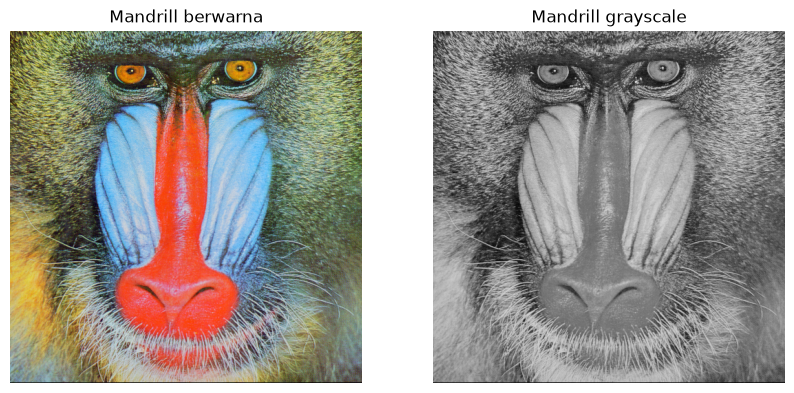

In [5]:
img      = baca('mandrill.tiff')                 # citra berwarna (BGR)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)   # citra keabuan 2D

print('Berwarna :', img.shape, img.dtype)
print('Keabuan  :', img_gray.shape, img_gray.dtype, '| min-max =', img_gray.min(), '-', img_gray.max())
show_side_by_side([img, img_gray], ['Mandrill berwarna', 'Mandrill grayscale'], figsize=(10, 5))

### D.2.e–f Menentukan kernel dan memanggil fungsi konvolusi (contoh: Sharpen)

**Kenapa kernel sharpen `[0,-1,0; -1,5,-1; 0,-1,0]`?**
Jumlah elemennya = `5 - 4 = 1` → kecerahan rata-rata **tidak berubah**. Ia setara dengan *citra asli + Laplacian*: `5 = 1 (asli) + 4 (Laplacian)`. Piksel pusat diperkuat, selisihnya dengan 4 tetangga ditambahkan → tepi jadi lebih tajam.

Ukuran asli          : (512, 512)
padding=2 (modul)    : (514, 514)
padding=1 (same size): (512, 512)


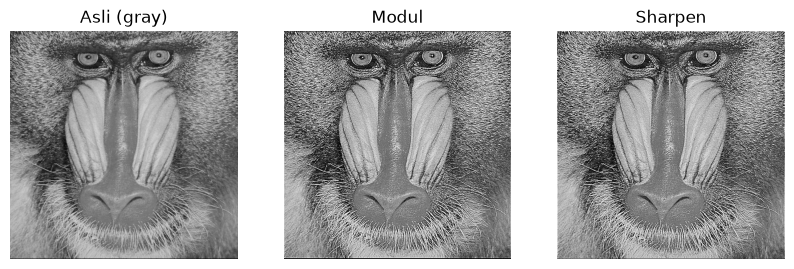

In [6]:
# image sharpen
kernel_sharpen = np.array([[ 0,-1, 0],
                           [-1, 5,-1],
                           [ 0,-1, 0]])

# Pemanggilan seperti modul: (citra, kernel, stride=1, padding=2) -> ukuran output bertambah 2 piksel/sisi
hasil_modul = convolution2d(img_gray, kernel_sharpen, 1, 2)
# Pemanggilan yang lebih tepat untuk analisis: padding=1 agar ukuran sama dengan citra asli
hasil_sharp = convolution2d(img_gray, kernel_sharpen, 1, 1)

print('Ukuran asli          :', img_gray.shape)
print('padding=2 (modul)    :', hasil_modul.shape)
print('padding=1 (same size):', hasil_sharp.shape)

show_side_by_side([img_gray, ke_uint8(hasil_modul, 'clip'),ke_uint8(hasil_sharp, 'clip')], 
                ['Asli (gray)', 'Modul', 'Sharpen'], figsize=(10, 5))

## D.3 Image Filter: Average, Low Pass, High Pass, dan tabel filter modul

memakai `convolution2d`  dengan `stride=1` dan `padding=(K-1)/2`.

**Cara cepat membaca sebuah kernel (sangat berguna saat studi kasus):**

| Jumlah elemen kernel | Artinya | Contoh |
|---|---|---|
| **= 1** | kecerahan rata-rata dipertahankan → *smoothing* atau *sharpening* | Average (⅑·ones), Gaussian, Sharpen |
| **= 0** | area rata menjadi hitam, hanya perubahan (tepi/titik/garis) yang muncul → *deteksi* | Sobel, Prewitt, Roberts, Laplacian, Point, Line |
| **> 1** | hasil lebih terang dari asli | – |
| elemen **semua positif** | perata (blur / low pass) | Average, Gaussian |
| ada elemen **negatif + positif** | pembeda / penguat selisih (high pass) | Sharpen, Edge |

### Sharpen dan Emboss
- **Sharpen** → tampil dengan `clip` (nilainya masih rentang terang wajar).
- **Emboss** → jumlah kernel = 1 (`-2-1+0-1+1+1+0+1+2 = 1`) namun karena komponen tanda +/− melambangkan arah, hasil terbaik dilihat dengan `offset` (+128) agar tampak seperti relief abu-abu, mirip contoh di modul.

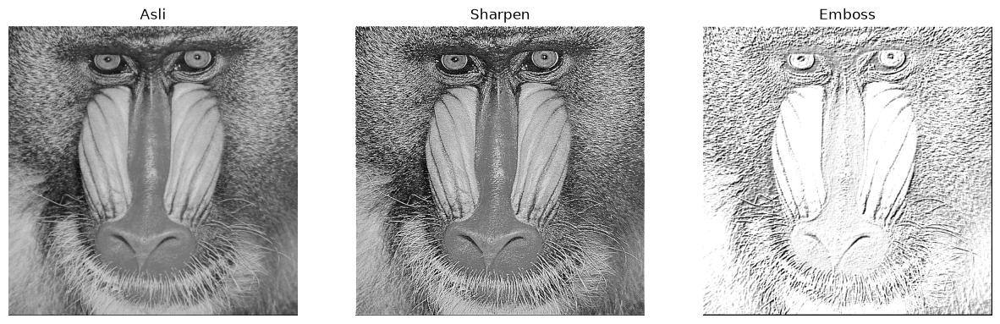

In [7]:
kernel_emboss = np.array([[-2,-1, 0],
                          [-1, 1, 1],
                          [ 0, 1, 2]])

sharpen = convolution2d(img_gray, kernel_sharpen, 1, 1)
emboss  = convolution2d(img_gray, kernel_emboss,  1, 1)

show_side_by_side([img_gray, ke_uint8(sharpen, 'clip'), ke_uint8(emboss, 'offset')],
                  ['Asli', 'Sharpen', 'Emboss'])

### Left Sobel Edge Detection dan "Canny" kernel (modul)

- Karena jumlah kernel = 0 → tampil dengan mode `abs`.

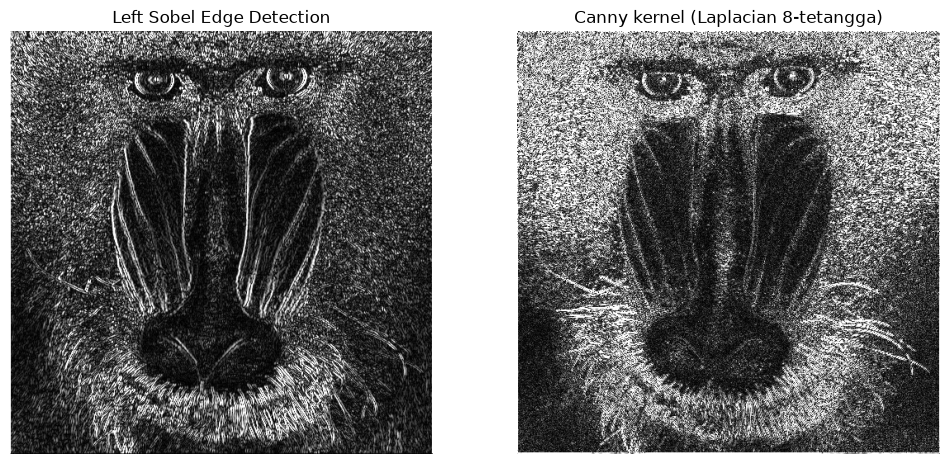

In [8]:
kernel_left_sobel = np.array([[1, 0,-1],
                              [2, 0,-2],
                              [1, 0,-1]])
kernel_canny = np.array([[-1,-1,-1],
                         [-1, 8,-1],
                         [-1,-1,-1]])

left_sobel = convolution2d(img_gray, kernel_left_sobel, 1, 1)
canny_k    = convolution2d(img_gray, kernel_canny,      1, 1)

show_side_by_side([ke_uint8(left_sobel, 'abs'), ke_uint8(canny_k, 'abs')],
                  ['Left Sobel Edge Detection', 'Canny kernel (Laplacian 8-tetangga)'], figsize=(12, 6))

### Gaussian Blur 21×21

Modul memberi rumus pembuat kernel:
`sigma = sqrt(kernel_size)`, `getGaussianKernel(kernel_size, sigma)`, lalu `kernel2D = k @ k.T`.

**Kenapa kernel 2D dibuat dari perkalian dua kernel 1D?** Gaussian bersifat *separable*: `G(x,y) = g(x)·g(y)`. `getGaussianKernel` menghasilkan vektor kolom 21×1 yang sudah ternormalisasi (jumlah = 1), maka `k @ k.T` menjadi matriks 21×21 yang jumlahnya juga 1 → kecerahan citra terjaga.

**Perbandingan A vs B:** kernel rata-rata 21×21 (kotak, semua bobot sama) vs Gaussian 21×21 (bobot menurun ke tepi). Gaussian lebih halus alami dan tanpa artefak kotak.

Ukuran kernel : (21, 21) | jumlah bobot = 1.0


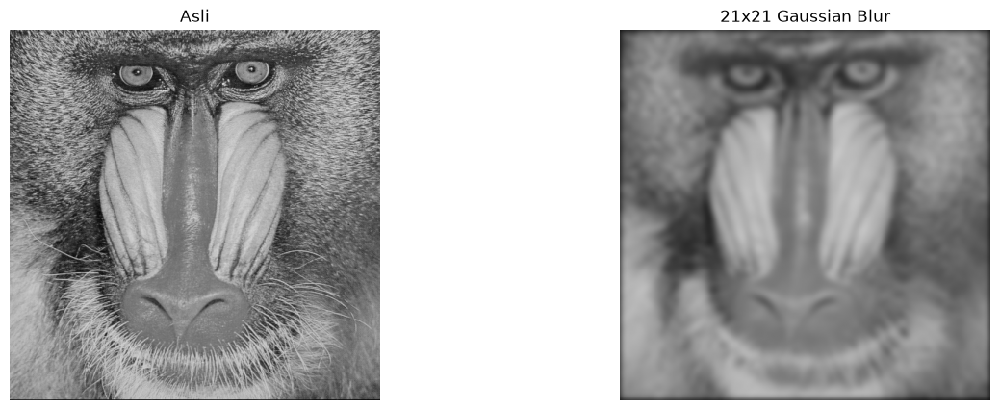

In [9]:
kernel_size = 21
sigma = math.sqrt(kernel_size)                       # = 4.58, sesuai modul
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)   # hanya untuk MEMBUAT bobot kernel
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose() # 21x21
print('Ukuran kernel :', gauss_kernel.shape, '| jumlah bobot =', round(gauss_kernel.sum(), 6))


gauss_blur = convolution2d(img_gray, gauss_kernel, 1, kernel_size // 2)

show_side_by_side([img_gray, ke_uint8(gauss_blur)],
                  ['Asli', '21x21 Gaussian Blur', ])

## E. Filter Library dan Filter Modern


In [10]:
lena     = baca('lena.jpg')
djawatan = baca('djawatan.jpg')
lena_gray = cv.cvtColor(lena, cv.COLOR_BGR2GRAY)
print('lena     :', lena.shape)
print('djawatan :', djawatan.shape)

lena     : (512, 512, 3)
djawatan : (720, 1080, 3)


### Percobaan 1 – Gaussian, Sharpen, Canny dengan library (citra RGB)

| Operasi | Fungsi | Parameter & alasan |
|---|---|---|
| Gaussian Blur | `cv.GaussianBlur(img, (7,7), 1)` | kernel 7×7 (harus ganjil), sigma 1 → blur ringan; sigma kecil relatif terhadap ukuran kernel supaya bobot tepi kernel hampir nol |
| Sharpen | `cv.filter2D(img, -1, kernel)` | `-1` = tipe output sama dengan input (uint8) sehingga **otomatis saturasi 0–255**. Pada citra warna, kernel diterapkan **ke tiap kanal** |
| Canny | `cv.Canny(gray, 100, 200)` | Canny **wajib input grayscale**. Ambang 100/200 (rasio 1:2) → tepi kuat >200, tepi lemah 100–200 dipertahankan hanya bila terhubung ke tepi kuat (hysteresis) |

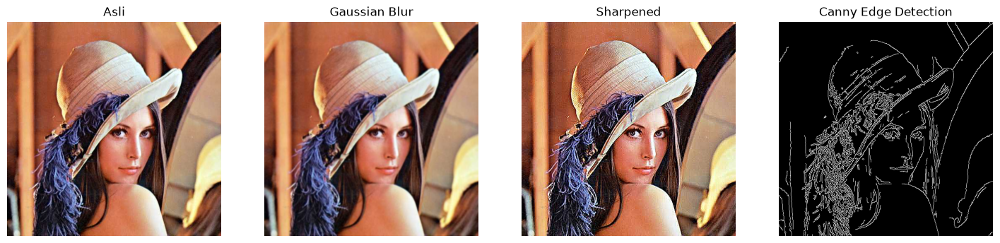

In [11]:
blur = cv.GaussianBlur(lena, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(lena, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
sharpened = cv.filter2D(lena, -1, sharpen_kernel)

show_side_by_side([lena, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"], figsize=(18, 5))

### Percobaan 2 – Filter modern: Bilateral dan Edge Preserving (pendekatan Guided Filter)

- **Bilateral filter** menimbang bobot piksel dengan **dua** hal: jarak spasial (`sigmaSpace`) **dan** perbedaan warna (`sigmaColor`). Piksel dengan warna sangat berbeda (tepi) bobotnya kecil → area datar dihaluskan, tepi tetap tajam.
  - `cv.bilateralFilter(img, d=50, 100, 100)` seperti modul. `d` besar = jendela besar = lambat.
- **Edge Preserving Filter** (`cv.edgePreservingFilter`) dipakai di modul sebagai alternatif Guided Filter (OpenCV inti tidak menyediakan `guidedFilter`; itu ada di `opencv-contrib`). `flags=1` = recursive filtering (cepat), `sigma_s` = luas spasial, `sigma_r` = sensitivitas warna (nilai kecil = tepi lebih dipertahankan).

**Perbandingan A vs B:** Gaussian (Percobaan 1) mengaburkan **tepi dan area datar sama rata**; Bilateral/Edge Preserving menghaluskan area datar tetapi menjaga tepi → hasil lebih "lukisan/halus".

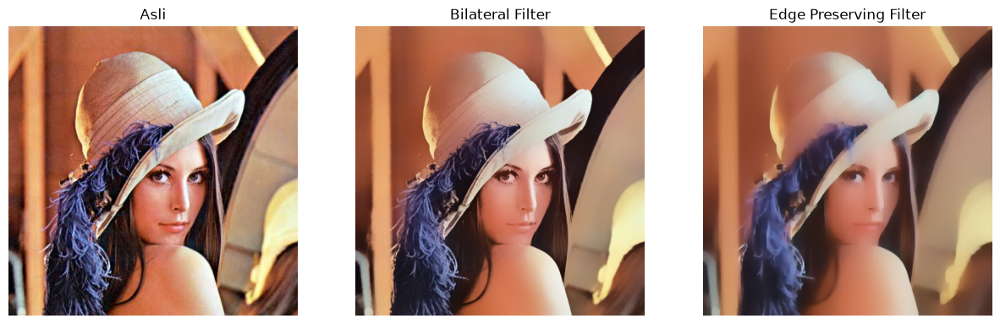

In [12]:
# Filter Modern dari OpenCV
bilateral = cv.bilateralFilter(lena, 50, 100, 100)                         # edge-preserving
edge_preserve = cv.edgePreservingFilter(lena, flags=1, sigma_s=100, sigma_r=0.9)  # alternatif Guided Filter

show_side_by_side([lena, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"], figsize=(15, 5))

### Percobaan 3 – Filter pada CNN (Feature Map)

`nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)` berarti: 1 kanal input, **4 filter** 3×3, `padding=1` agar ukuran sama.
Berbeda dengan Sobel/Gaussian, **isi kernel CNN tidak ditentukan manusia**: awalnya **acak**, lalu dipelajari saat training.


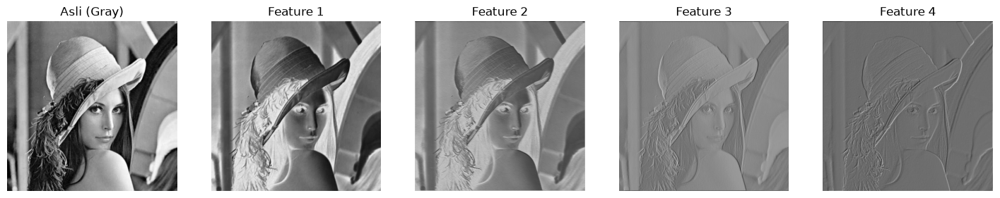

Run 1 - bobot filter 1 (3x3):
 [[ 0.   -0.12 -0.02]
 [-0.23 -0.23 -0.19]
 [-0.11 -0.26  0.28]]


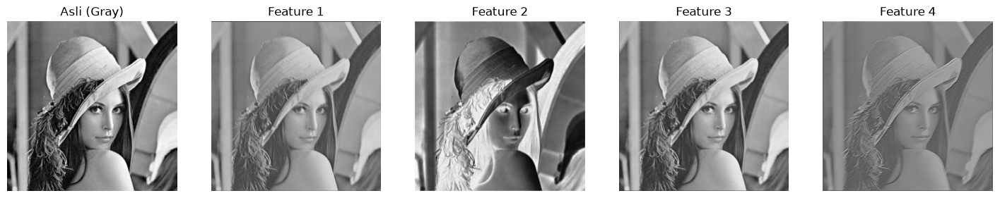

Run 2 - bobot filter 1 (3x3):
 [[ 0.3   0.07  0.04]
 [-0.29  0.14 -0.05]
 [-0.15  0.29  0.07]]


In [13]:
# Percobaan 3 membutuhkan PyTorch (sudah tersedia di Google Colab)
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

# Ubah gambar ke tensor: bentuk (batch=1, kanal=1, tinggi, lebar), skala 0-1
img_tensor = torch.tensor(lena_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

def jalankan_cnn(seed=None):
    if seed is not None:
        torch.manual_seed(seed)          # kunci inisialisasi bobot
    model = SimpleCNN()
    with torch.no_grad():
        features = model(img_tensor)
    return [features[0, i].numpy() for i in range(features.shape[1])], model

# Run 1 dan Run 2 TANPA seed -> hasil berbeda
for run in (1, 2):
    feature_maps, model = jalankan_cnn()
    feature_maps_vis = [ke_uint8(f, mode='minmax') for f in feature_maps]
    show_side_by_side([lena_gray] + feature_maps_vis,
                      ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps_vis))], figsize=(18, 4))
    print(f"Run {run} - bobot filter 1 (3x3):\n", np.round(model.conv1.weight[0, 0].detach().numpy(), 2))

In [14]:
# Dengan seed yang sama -> hasil identik
fm_a, _ = jalankan_cnn(seed=42)
fm_b, _ = jalankan_cnn(seed=42)
print('Seed sama -> feature map identik?', all(np.allclose(a, b) for a, b in zip(fm_a, fm_b)))

Seed sama -> feature map identik? True


**Kesimpulan Percobaan 3 :**
- Filter pada CNN adalah **kernel yang bobotnya dipelajari**, bukan diisi manual atau kira kira.
- Tanpa training, bobot acak menghasilkan feature map yang berbeda tiap run. ada yang menyerupai blur, penajaman, atau deteksi tepi.
- Setelah training, bobot akan menyesuaikan sehingga filter berfungsi mengekstraksi fitur yang berguna (tepi, tekstur, pola) untuk tugas tertentu.

### Percobaan 4 – Beauty Filter dan Old/Vintage Filter (kombinasi filter tradisional)

**Beauty filter** = 3 tahap:
1. `bilateralFilter` → haluskan tekstur kulit **tanpa** mengaburkan kontur (dibanding Gaussian biasa).
2. *Unsharp masking*: `sharpened = 1.5·smooth − 0.5·gaussian` → menajamkan mata/bibir. Rumus unsharp: `asli + k·(asli − blur)`; dengan k=0.5 menjadi `1.5·asli − 0.5·blur`.
3. `convertScaleAbs(alpha=1.2, beta=15)` → kontras ×1.2 dan kecerahan +15 (`g = α·f + β`, hasil dikunci 0–255).

**Vintage filter** = 3 tahap:
1. Sepia: perkalian matriks warna 3×3 pada setiap piksel (`cv.transform`).
2. Vignette: mask Gaussian 2D (tepi gelap, tengah terang) dikalikan ke semua kanal.
3. Grain: tambah noise Gaussian (`sigma=15`) supaya tampak film lama. Tipe dikonversi ke `int16` saat penjumlahan agar nilai negatif/>255 tidak overflow, baru di-`clip`.

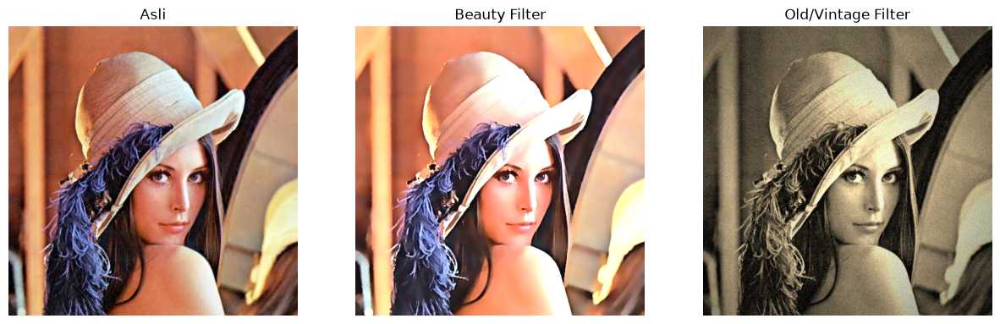

In [15]:
img = lena

# 1. Beauty Filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)             # Step 1: haluskan kulit
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened_b = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)                     # Step 2: unsharp masking
alpha = 1.2   # contrast
beta = 15     # brightness
beauty = cv.convertScaleAbs(sharpened_b, alpha=alpha, beta=beta)                 # Step 3

# 2. Old/Vintage Filter
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)                                           # Step 1: sepia
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):                                                                # Step 2: vignette
    vignette[:, :, i] = vignette[:, :, i] * mask

noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)                  # Step 3: grain
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"], figsize=(15, 5))

### Percobaan 5 – Filter Anime / Cartoon

Ide: kartun = **warna rata** + **garis tepi hitam tegas**.
1. Gray → `medianBlur(7)` dahulu agar noise kecil tidak terbaca sebagai garis.
2. `adaptiveThreshold` (mean, blok 9, C=9) → mask garis (tepi=0 hitam, lainnya=255). Dipilih *adaptive* karena ambang dihitung **lokal**, jadi garis tetap muncul di area gelap maupun terang (global threshold akan gagal).
3. `bilateralFilter` pada citra warna → meratakan warna tanpa merusak batas objek.
4. `bitwise_and(color, color, mask=edges)` → warna hanya ditampilkan di tempat mask = 255; di garis (mask = 0) menjadi hitam.

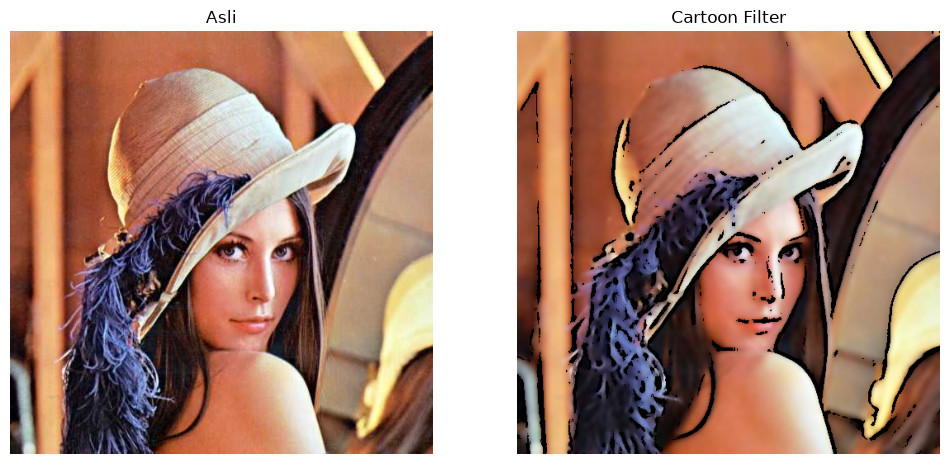

In [16]:
#Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(lena, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(lena, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([lena, cartoon], ["Asli", "Cartoon Filter"], figsize=(12, 6))

### Percobaan 6 – Night Filter (+ glow dengan `filter2D`)

1. Gelapkan: `convertScaleAbs(alpha=0.6, beta=-40)` → kontras turun, kecerahan dikurangi.
2. Tint: campur 80% citra gelap + 20% warna konstan `(B=50, G=0, R=100)` dengan `addWeighted`. *(Urutan OpenCV adalah BGR, jadi nilai ini sebenarnya condong ke ungu-kemerahan; untuk biru yang lebih murni naikkan kanal pertama, mis. `(100, 0, 50)`.)*
3. Glow: blur dengan kernel rata-rata 15×15 (`ones/225`) memakai `filter2D`, lalu campur 70% citra malam + 30% versi blur → cahaya "meluber".

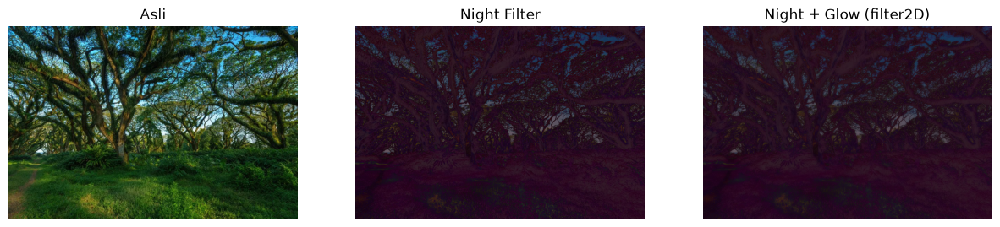

In [17]:
#Night Filter
img = djawatan

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow], ["Asli", "Night Filter", "Night + Glow (filter2D)"])

### Percobaan 7 – Filter Pagi dan Pagi + Kabut

1. Kurangi kontras & cerahkan (`alpha=0.9`, `beta=20`) → tampilan lembut.
2. Warm tint oranye `(B=40,G=70,R=120)` 20% → suasana matahari pagi.
3. Kabut: blur Gaussian 3×3 (`getGaussianKernel(3,3)` lalu `k @ k.T`) + layer putih 30% → menurunkan kontras & menambah kesan kabut tipis.

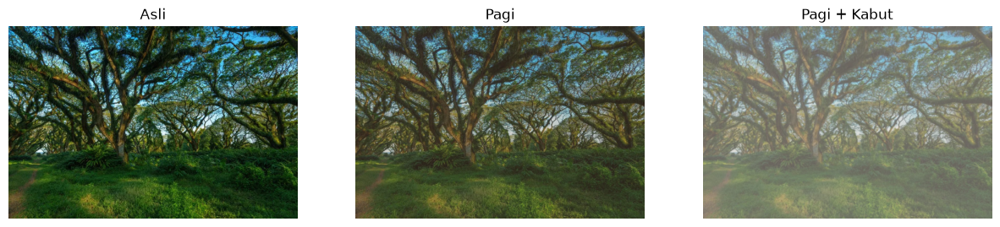

In [18]:
#Filter Suasana pagi dan Kabut
img = djawatan

# Step 1: Kurangi kontras & cerahkan
alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# Step 2: Tambahkan warm tone (kemerahan / oranye)
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut], ["Asli", "Pagi", "Pagi + Kabut"])

---
# Tugas Praktikum

## Tugas 1 – Mean Filter vs Median Filter pada Noise *Salt and Pepper*

**Alur berpikir:**
1. **Buat noise yang terkontrol** → `tambah_salt_pepper(gray, jumlah, seed)`. Seed dikunci supaya hasil bisa direproduksi. Piksel acak diset 0 (pepper) atau 255 (salt) dengan proporsi sama.
2. **Terapkan dua filter 3×3** → Mean (`cv.blur`) dan Median (`cv.medianBlur`). Kita juga membuktikan `cv.blur` = `convolution2d` buatan sendiri dengan kernel ⅑.
3. **Ukur, jangan hanya lihat** → MSE & PSNR terhadap citra bersih (PSNR makin tinggi = makin mirip asli).

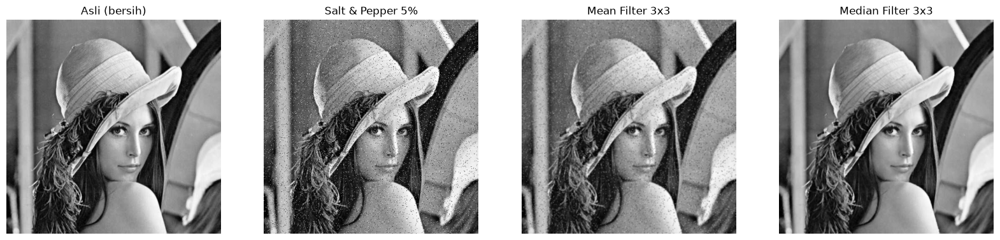

Citra                    MSE  PSNR (dB)
Noisy                1014.50      18.07
Mean 3x3              167.17      25.90
Median 3x3             31.43      33.16


In [19]:
def tambah_salt_pepper(gray, jumlah=0.05, seed=42):
    # jumlah = proporsi piksel yang rusak (0.05 = 5%); setengah jadi hitam, setengah putih
    rng = np.random.default_rng(seed)
    noisy = gray.copy()
    acak = rng.random(gray.shape)
    noisy[acak < jumlah / 2] = 0              # pepper
    noisy[acak > 1 - jumlah / 2] = 255        # salt
    return noisy

def mse(a, b):
    return np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)

def psnr(a, b):
    m = mse(a, b)
    return float('inf') if m == 0 else 10 * np.log10(255 ** 2 / m)

asli_gray = lena_gray                                  # citra keabuan bersih
noisy     = tambah_salt_pepper(asli_gray, 0.05)        # (a) tambahkan noise 5%

mean_f   = cv.blur(noisy, (3, 3))                      # (b) Mean Filter 3x3
median_f = cv.medianBlur(noisy, 3)                     #     Median Filter 3x3

show_side_by_side([asli_gray, noisy, mean_f, median_f],
                  ['Asli (bersih)', 'Salt & Pepper 5%', 'Mean Filter 3x3', 'Median Filter 3x3'], figsize=(20, 5))

print(f'{"Citra":18s} {"MSE":>9s} {"PSNR (dB)":>10s}')
for nama, citra in [('Noisy', noisy), ('Mean 3x3', mean_f), ('Median 3x3', median_f)]:
    print(f'{nama:18s} {mse(asli_gray, citra):9.2f} {psnr(asli_gray, citra):10.2f}')

Selisih maksimum (area dalam, tanpa tepi) = 0.444 (<=0.5 hanya karena pembulatan uint8)


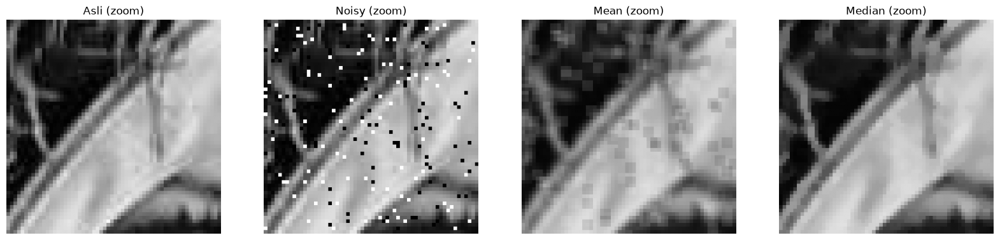

In [20]:
# Bukti: Mean Filter library = konvolusi buatan sendiri dengan kernel 1/9
mean_manual = convolution2d(noisy, np.ones((3, 3)) / 9, 1, 1)
selisih = np.abs(mean_manual[1:-1, 1:-1] - mean_f[1:-1, 1:-1].astype(np.float64)).max()
print('Selisih maksimum (area dalam, tanpa tepi) =', round(selisih, 3), '(<=0.5 hanya karena pembulatan uint8)')

# (c) Zoom: perbesar potongan 60x60 piksel (INTER_NEAREST agar piksel tidak dihaluskan)
def zoom(c, y=200, x=220, s=60, f=5):
    return cv.resize(c[y:y+s, x:x+s], None, fx=f, fy=f, interpolation=cv.INTER_NEAREST)

show_side_by_side([zoom(asli_gray), zoom(noisy), zoom(mean_f), zoom(median_f)],
                  ['Asli (zoom)', 'Noisy (zoom)', 'Mean (zoom)', 'Median (zoom)'], figsize=(20, 5))

### Kenapa Median jauh lebih bersih? – bukti angka pada satu jendela 3×3
Misal piksel sebenarnya ≈ 100, tetapi satu tetangga rusak menjadi **255** (salt) dan satu menjadi **0** (pepper).

In [21]:
jendela = np.array([100, 102, 255, 101, 0, 99, 103, 100, 101])   # 9 nilai dalam jendela 3x3
print('Nilai terurut :', np.sort(jendela))
print('Mean          =', round(jendela.mean(), 1), '-> terseret oleh 255 dan 0 (outlier ikut dihitung)')
print('Median        =', np.median(jendela), '-> nilai tengah; 0 dan 255 berada di ujung urutan sehingga DIABAIKAN')

Nilai terurut : [  0  99 100 100 101 101 102 103 255]
Mean          = 106.8 -> terseret oleh 255 dan 0 (outlier ikut dihitung)
Median        = 101.0 -> nilai tengah; 0 dan 255 berada di ujung urutan sehingga DIABAIKAN


In [22]:
# Uji berbagai tingkat noise: kapan Median mulai gagal?
print(f'{"Noise":>6s} | {"PSNR Noisy":>10s} {"PSNR Mean":>10s} {"PSNR Median":>12s}')
for jumlah in [0.02, 0.05, 0.10, 0.20, 0.40]:
    n = tambah_salt_pepper(asli_gray, jumlah)
    print(f'{jumlah*100:5.0f}% | {psnr(asli_gray, n):10.2f} {psnr(asli_gray, cv.blur(n, (3,3))):10.2f} {psnr(asli_gray, cv.medianBlur(n, 3)):12.2f}')

 Noise | PSNR Noisy  PSNR Mean  PSNR Median
    2% |      21.97      28.55        33.67
    5% |      18.07      25.90        33.16
   10% |      15.03      23.13        32.06
   20% |      12.01      19.93        28.38
   40% |       9.02      16.19        18.50


**Analisis menapa median filter jauh lebih bersih:**
- **Mean filter** menghitung rata-rata seluruh piksel tetangga. Nilai ekstrem (0 atau 255) ikut dihitung sehingga *tidak dihilangkan*, hanya **disebar** ke piksel sekitarnya → bintik berubah menjadi bercak abu-abu dan citra ikut kabur (tepi melembut). Salah satu bintik bahkan memengaruhi 9 piksel keluaran.
- **Median filter** mengurutkan 9 nilai lalu mengambil nilai tengah. Selama jumlah outlier dalam jendela < 5 dari 9, 0/255 berada di ujung urutan dan **tidak pernah terpilih**; nilai yang keluar adalah nilai nyata dari piksel tetangga → noise **hilang**, tepi tetap relatif tajam.
- Median adalah filter **non-linear** (tidak bisa dinyatakan dengan kernel), mean adalah filter **linear** (kernel ⅑).
- Dari tabel PSNR: Median unggul pada noise rendah–sedang; pada noise sangat tinggi (≥ ±40%) jendela 3×3 sering berisi >4 outlier sehingga Median pun mulai anjlok.


## Tugas 2 – Memilih Ukuran Kernel Terbaik untuk Sharpening (3×3 vs 5×5)

**Alur Pembuatan:**
1. **Siapkan citra "sedikit buram" dengan kebenaran dasar.** Ambil citra tajam (lena gray), buramkan dengan Gaussian σ=1.5 → kita tahu citra tajam aslinya sehingga hasil sharpening bisa **diukur** (PSNR terhadap aslinya). Tambahkan juga noise kecil (σ=3) untuk meniru noise kamera.
2. **Buat kernel** (jumlah kernel harus **1** supaya kecerahan tidak berubah):
   - 3×3 : `[0,-1,0; -1,5,-1; 0,-1,0]`
   - 5×5 : kernel penajam klasik `1/8·[-1 ×16 tepi, 2 ×8 cincin dalam, 8 pusat]`
   - 5×5 unsharp (bonus pembanding berkekuatan setara): `2·δ − Gaussian5×5`
3. **Terapkan** ke citra buram bersih & berderau.
4. **Evaluasi dua aspek sesuai soal:**
   - *Kejelasan tepi*: rata-rata magnitudo gradien Sobel (makin dekat ke nilai citra tajam asli, makin baik) + PSNR terhadap citra tajam asli.
   - *Kadar noise/distorsi*: `std` noise keluaran = simpangan baku selisih hasil(citra berderau) − hasil(citra bersih), dan **noise gain** teoretis `√Σk²`.

In [23]:
# 1) Citra tajam asli -> dibuat sedikit buram -> ditambah noise kecil
tajam  = lena_gray
buram  = cv.GaussianBlur(tajam, (0, 0), 1.5)                          # sedikit buram
rng    = np.random.default_rng(0)
buram_noise = np.clip(buram + rng.normal(0, 3, buram.shape), 0, 255).astype(np.float64)

# 2) Kernel penajaman
k3 = np.array([[ 0,-1, 0],
               [-1, 5,-1],
               [ 0,-1, 0]])
k5 = np.array([[-1,-1,-1,-1,-1],
               [-1, 2, 2, 2,-1],
               [-1, 2, 8, 2,-1],
               [-1, 2, 2, 2,-1],
               [-1,-1,-1,-1,-1]]) / 8
g5 = cv.getGaussianKernel(5, 1.0); g5 = g5 @ g5.T
delta = np.zeros((5, 5)); delta[2, 2] = 1
k5_unsharp = 2 * delta - g5                                            # = asli + (asli - blur)

kernels = {'3x3 (Laplacian)': k3, '5x5 (klasik)': k5, '5x5 (unsharp)': k5_unsharp}
for n, k in kernels.items():
    print(f'{n:18s} jumlah kernel = {k.sum():.2f} | noise gain sqrt(sum k^2) = {np.sqrt((k**2).sum()):.2f}')

3x3 (Laplacian)    jumlah kernel = 1.00 | noise gain sqrt(sum k^2) = 5.39
5x5 (klasik)       jumlah kernel = 1.00 | noise gain sqrt(sum k^2) = 1.32
5x5 (unsharp)      jumlah kernel = 1.00 | noise gain sqrt(sum k^2) = 1.85


Citra / kernel      Kejelasan tepi  PSNR vs tajam  Noise keluaran (std)
Citra  Asli (ref)            62.60              -                     -
Buram (input)                39.97          28.04                  3.00
3x3 (Laplacian)              51.71          27.72                 16.18
5x5 (klasik)                 56.32          28.84                  3.98
5x5 (unsharp)                44.60          28.76                  5.57


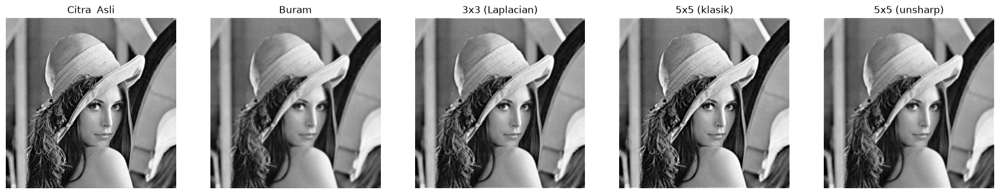

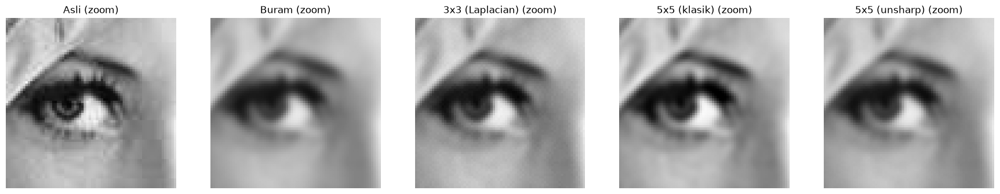

In [24]:
# 3) Terapkan memakai convolution2d buatan sendiri (padding=(K-1)/2)
def gradien_rata(c):
    gx = cv.Sobel(c.astype(np.float64), cv.CV_64F, 1, 0, ksize=3)
    gy = cv.Sobel(c.astype(np.float64), cv.CV_64F, 0, 1, ksize=3)
    return np.mean(np.sqrt(gx**2 + gy**2))

hasil_bersih, hasil_noise = {}, {}
for n, k in kernels.items():
    p = k.shape[0] // 2
    hasil_bersih[n] = np.clip(convolution2d(buram, k, 1, p), 0, 255)
    hasil_noise[n]  = convolution2d(buram_noise, k, 1, p)      # tanpa clip agar std noise tidak bias

# 4) Evaluasi
print(f'{"Citra / kernel":18s} {"Kejelasan tepi":>15s} {"PSNR vs tajam":>14s} {"Noise keluaran (std)":>21s}')
print(f'{"Citra  Asli (ref)":18s} {gradien_rata(tajam):15.2f} {"-":>14s} {"-":>21s}')
print(f'{"Buram (input)":18s} {gradien_rata(buram):15.2f} {psnr(tajam, buram):14.2f} {3.0:21.2f}')
for n in kernels:
    # noise keluaran = std( filter(buram_noise) - filter(buram) ), dihitung tanpa clip
    k = kernels[n]; p = k.shape[0] // 2
    sel = convolution2d(buram_noise, k, 1, p) - convolution2d(buram.astype(np.float64), k, 1, p)
    print(f'{n:18s} {gradien_rata(hasil_bersih[n]):15.2f} {psnr(tajam, hasil_bersih[n]):14.2f} {np.std(sel):21.2f}')

show_side_by_side([tajam, buram] + [hasil_bersih[n].astype(np.uint8) for n in kernels],
                  ['Citra  Asli', 'Buram'] + list(kernels.keys()), figsize=(22, 5))

# Zoom bagian mata untuk melihat tepi & halo
def zoom2(c, y=230, x=240, s=70, f=4):
    return cv.resize(np.asarray(c, dtype=np.uint8)[y:y+s, x:x+s], None, fx=f, fy=f, interpolation=cv.INTER_NEAREST)
show_side_by_side([zoom2(tajam), zoom2(buram)] + [zoom2(hasil_bersih[n]) for n in kernels],
                  ['Asli (zoom)', 'Buram (zoom)'] + [n + ' (zoom)' for n in kernels], figsize=(22, 5))

### **Kesimpulan Tugas 2: Pemilihan Ukuran Kernel Sharpening Terbaik**

Berdasarkan hasil uji coba penajaman (*sharpening*) pada citra buram:

#### **1. Karakteristik Masing-Masing Kernel:**
* **Kernel 3x3 (Laplacian):**
  * **Efek:** Garis tepi memang menjadi lebih tegas, **tetapi bintik-bintik (*noise*) ikut membesar tajam hingga ±5 kali lipat**.
  * **Kekurangan:** Gambar terlihat berbintik kasar/pecah-pecah karena noise kecil ikut dipertajam (nilai PSNR justru turun).
* **Kernel 5x5 (Klasik):**
  * **Efek:** Garis tepi pulih dengan sangat baik dan **bintik noise tetap tenang (hanya naik sedikit)**.
  * **Kelebihan:** Memberikan kualitas gambar terbaik (skor kemiripan/PSNR paling tinggi) karena area jendelanya yang lebih lebar mampu membedakan mana garis gambar asli dan mana bintik acak.
* **Kernel 5x5 (Unsharp Mask):**
  * **Efek:** Sangat aman dan minim noise, namun efek penajamannya terasa agak kurang tegas.

---

#### **2. Kesimpulan & Rekomendasi Penggunaan Sehari-hari:**

> **Pilihan Paling Optimal: Kernel 5x5 (Klasik)**
>
> Untuk kebutuhan sehari-hari (seperti foto HP, foto minim cahaya, atau gambar kompresi):
> 1. **Kernel 5x5 Klasik adalah yang paling seimbang**, karena berhasil membuat gambar buram menjadi tajam tanpa merusak foto dengan bintik-bintik kasar (*noise*).
> 2. **Kernel 3x3 hanya cocok** jika gambar awalnya benar-benar sangat mulus dan bersih dari bintik noise (misalnya gambar ilustrasi digital atau hasil desain grafis).


## Tugas 3 – Filter Kartun Sederhana: fungsi `kartun(image)`

**Alur Pembuatan:**
1. **Penghalusan warna → Bilateral Filter.** Dipilih (bukan Gaussian) karena meratakan area warna tetapi **menjaga batas objek**. Parameter `d=9`, `sigmaColor=200`, `sigmaSpace=200` → warna benar-benar rata ("flat" ala kartun). Agar lebih cepat dan lebih rata, filter bisa diulang 2–3×.
2. **Deteksi garis tepi → Adaptive Thresholding *atau* Canny.** Fungsi menerima parameter `metode`:
   - `'adaptive'` → garis tebal & kontinu, gaya komik (default modul).
   - `'canny'` → garis tipis & presisi; hasil Canny (tepi putih di latar hitam) harus **di-invert** dan agak ditebalkan (`dilate`) supaya setara dengan mask adaptive.
   Sebelum itu citra gray di-`medianBlur` agar noise tidak jadi garis liar.
3. **Penggabungan → operasi logika / perkalian piksel.** Mask garis bernilai 0 (garis) dan 255 (bukan garis). Dengan `bitwise_and` garis menjadi hitam. Setara dengan **perkalian** `warna × (mask/255)`; keduanya dibuktikan identik pada sel di bawah.

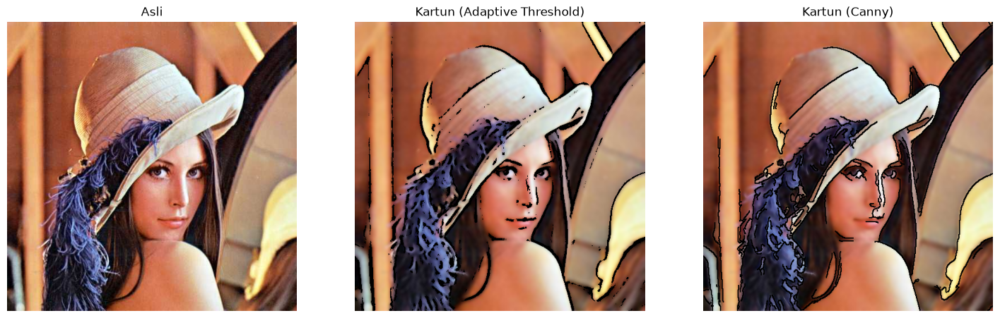

In [ ]:
def kartun(image, metode='adaptive', d=9, sigma_color=200, sigma_space=200, ulang=1):
    # Filter kartun sederhana.
    # image  : citra BGR
    # metode : 'adaptive' (Adaptive Thresholding) atau 'canny' (Canny Edge)
    # 1) Penghalusan warna dengan Bilateral Filter (boleh diulang agar lebih rata)
    warna = image.copy()
    for _ in range(ulang):
        warna = cv.bilateralFilter(warna, d, sigma_color, sigma_space)

    # 2) Deteksi garis tepi
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray = cv.medianBlur(gray, 7)                      # redam noise supaya garis bersih
    if metode == 'adaptive':
        garis = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_MEAN_C,
                                     cv.THRESH_BINARY, 9, 9)       # garis=0, lainnya=255
    elif metode == 'canny':
        tepi = cv.Canny(gray, 80, 160)                 # tepi=255 (putih)
        tepi = cv.dilate(tepi, np.ones((2, 2), np.uint8))          # tebalkan sedikit
        garis = cv.bitwise_not(tepi)                   # invert -> garis=0, lainnya=255
    else:
        raise ValueError("metode harus 'adaptive' atau 'canny'")

    # 3) Gabungkan: warna hanya tampil di tempat bukan garis
    hasil = cv.bitwise_and(warna, warna, mask=garis)
    return hasil

# (b) Tampilkan citra asli dengan efek kartun bersebelahan
kartun_adaptive = kartun(lena, metode='adaptive')
kartun_canny    = kartun(lena, metode='canny')
show_side_by_side([lena, kartun_adaptive, kartun_canny],
                  ['Asli', 'Kartun (Adaptive Threshold)', 'Kartun (Canny)'], figsize=(18, 6))

bitwise_and sama dengan perkalian piksel? True


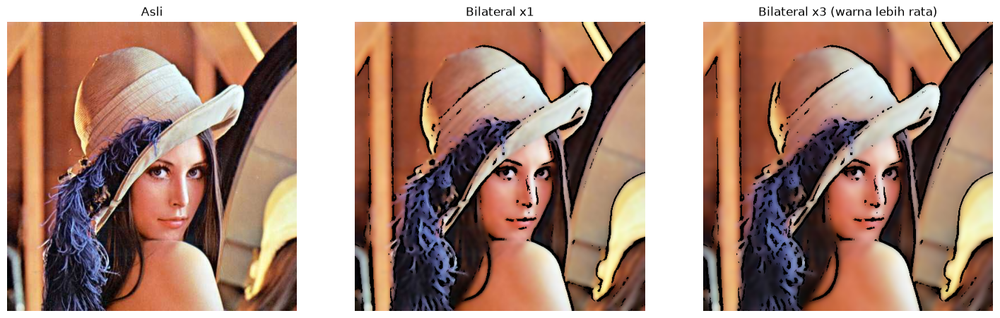

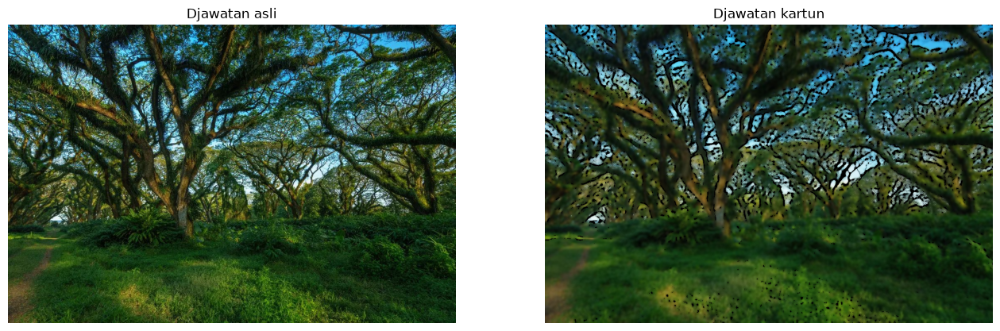

In [ ]:
# Bukti: bitwise_and dengan mask  ==  perkalian piksel warna x (mask/255)
warna = cv.bilateralFilter(lena, 9, 200, 200)
mask  = cv.adaptiveThreshold(cv.medianBlur(cv.cvtColor(lena, cv.COLOR_BGR2GRAY), 7), 255,
                             cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)
gabung_and  = cv.bitwise_and(warna, warna, mask=mask)
gabung_kali = (warna * (mask[:, :, None] / 255.0)).astype(np.uint8)
print('bitwise_and sama dengan perkalian piksel?', np.array_equal(gabung_and, gabung_kali))

# Efek pengulangan bilateral (ulang=1 vs 3) -> warna makin rata
show_side_by_side([lena, kartun(lena, ulang=1), kartun(lena, ulang=3)],
                  ['Asli', 'Bilateral x1', 'Bilateral x3 (warna lebih rata)'], figsize=(18, 6))

# Fungsi yang sama dapat dipakai pada citra lain
show_side_by_side([djawatan, kartun(djawatan)], ['Djawatan asli', 'Djawatan kartun'], figsize=(16, 6))

---
## Ringkasan Akhir: Panduan Memilih Filter (Bahasa Sederhana)

Supaya tidak bingung memilih filter saat mengerjakan pengolahan citra, berikut panduan mudahnya:

| Masalah pada Foto | Filter yang Dipakai | Penjelasan Singkat (Kenapa Memilih Ini?) |
|---|---|---|
| **Bintik putih-hitam (*Salt & Pepper*)** | **Median Filter** | Paling ampuh! Mengambil nilai tengah, sehingga bintik kotoran langsung hilang bersih. |
| **Foto buram / kurang jelas** | **Sharpening (5x5 Klasik)** | Membuat garis tepi tajam kembali tanpa membuat foto jadi berbintik kasar. |
| **Foto bintik halus merata (*Noise*)** | **Gaussian / Bilateral** | Menghaluskan permukaan foto. |
| **Edit wajah / kulit (efek glowing)** | **Bilateral Filter** | Menghaluskan pori-pori dan kulit, tapi garis mata, alis, dan bibir tetap tajam. |
| **Ingin mencari garis batas objek** | **Sobel / Canny** | Menghapus warna isi dan hanya menyisakan garis tepi luar objek. |
| **Bikin efek gambar kartun / anime** | **Bilateral + Garis Tepi** | Warna dibuat rata mulus seperti cat, lalu ditimpa garis tepi tebal berwarna hitam. |
| **Efek nuansa (malam / pagi / jadul)** | **Color Tint + Brightness** | Mengubah gelap-terang dan menggeser nuansa warna (misal: biru untuk malam, kuning hangat untuk jadul). |

---
> **Aturan Gampang Mengingat Rumus Kernel:**
> * Jika semua angka di dalam kernel **dijumlahkan hasilnya = 1**, tujuannya untuk **memperbaiki foto** (menghaluskan atau menajamkan).
> * Jika semua angka di dalam kernel **dijumlahkan hasilnya = 0**, tujuannya untuk **mencari tepi/garis/titik** (area rata jadi hitam, hanya garis yang menyala).
